# wafer defect runs

Runtime: A100 + high RAM. Needs `KAGGLE_USERNAME` and `KAGGLE_KEY` in Colab secrets (or `KAGGLE_API_TOKEN`). Outputs get copied to Drive under `wafer-defect-swin/`.

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
!pip install -q git+https://github.com/arihaaant/wafer-defect-swin.git kagglehub

name, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os, glob, json, shutil, time
from google.colab import userdata, drive

for key in ['KAGGLE_API_TOKEN', 'KAGGLE_USERNAME', 'KAGGLE_KEY']:
    try:
        os.environ[key] = userdata.get(key)
    except Exception:
        pass

import kagglehub
data_dir = kagglehub.dataset_download('qingyi/wm811k-wafer-map')
lswmd = glob.glob(f'{data_dir}/**/LSWMD.pkl', recursive=True)[0]

drive.mount('/content/drive')
stamp = time.strftime('%Y%m%d-%H%M')
out = f'/content/runs/{stamp}'
drive_out = f'/content/drive/MyDrive/wafer-defect-swin/{stamp}'
os.makedirs(out, exist_ok=True)
print(lswmd, drive_out)

100%|██████████| 149M/149M [00:04<00:00, 34.9MB/s]

Extracting files...


Mounted at /content/drive
/root/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1/LSWMD.pkl /content/drive/MyDrive/wafer-defect-swin/20260930-1749


In [3]:
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from waferdefect import data
from waferdefect.train import Config, train

df = data.load_lswmd(lswmd)
workers = min(os.cpu_count(), 12)
print(len(df))
df['failureType'].value_counts()

25519


,count
failureType,
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555
Near-full,149


## training runs

In [4]:
runs = {
    'base': {},
    'no_mixup': {'mixup_alpha': 0.0},
    'sampler_only': {'class_weights': False},
    'weights_only': {'balanced_sampler': False},
    'no_rebalance': {'balanced_sampler': False, 'class_weights': False},
}
results = {}
for name, kw in runs.items():
    t0 = time.time()
    results[name] = train(Config(data=lswmd, out=f'{out}/{name}', num_workers=workers, **kw), df=df)
    results[name]['minutes'] = round((time.time() - t0) / 60, 1)
    shutil.copytree(f'{out}/{name}', f'{drive_out}/{name}', dirs_exist_ok=True)

pd.DataFrame({k: {'val_f1': v['val_macro_f1'], 'test_f1': v['test_macro_f1'], 'test_acc': v['test_accuracy'],
                  'epoch': v['best_epoch'], 'min': v['minutes']} for k, v in results.items()}).T.round(4)

device=cuda amp=torch.bfloat16 train=17863 val=3828 test=3828


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

epoch 01  train loss 0.3377 f1 0.1993  val loss 0.0758 f1 0.1938  35s
epoch 02  train loss 0.1604 f1 0.2701  val loss 0.0512 f1 0.3151  25s
epoch 03  train loss 0.1372 f1 0.3261  val loss 0.0449 f1 0.3255  25s
epoch 04  train loss 0.1269 f1 0.3814  val loss 0.0418 f1 0.5086  26s
epoch 05  train loss 0.1170 f1 0.4160  val loss 0.0424 f1 0.5003  25s
epoch 06  train loss 0.1166 f1 0.4338  val loss 0.0405 f1 0.5593  25s
epoch 07  train loss 0.1106 f1 0.4182  val loss 0.0359 f1 0.6155  26s
epoch 08  train loss 0.0993 f1 0.4297  val loss 0.0362 f1 0.6291  25s
epoch 09  train loss 0.1018 f1 0.4397  val loss 0.0347 f1 0.6989  25s
epoch 10  train loss 0.1037 f1 0.4574  val loss 0.0345 f1 0.6804  26s
epoch 11  train loss 0.0928 f1 0.4579  val loss 0.0343 f1 0.6212  25s
epoch 12  train loss 0.0908 f1 0.4565  val loss 0.0326 f1 0.7393  25s
epoch 13  train loss 0.0921 f1 0.4636  val loss 0.0334 f1 0.7191  25s
epoch 14  train loss 0.0980 f1 0.4780  val loss 0.0323 f1 0.7346  25s
epoch 15  train loss

epoch 01  train loss 0.2131 f1 0.3123  val loss 0.0709 f1 0.2838  25s
epoch 02  train loss 0.0799 f1 0.4719  val loss 0.0484 f1 0.3818  24s
epoch 03  train loss 0.0598 f1 0.6425  val loss 0.0443 f1 0.4950  24s
epoch 04  train loss 0.0502 f1 0.7495  val loss 0.0456 f1 0.5157  24s
epoch 05  train loss 0.0448 f1 0.7963  val loss 0.0373 f1 0.6588  25s
epoch 06  train loss 0.0419 f1 0.8235  val loss 0.0386 f1 0.6312  24s
epoch 07  train loss 0.0389 f1 0.8381  val loss 0.0356 f1 0.7323  25s
epoch 08  train loss 0.0369 f1 0.8578  val loss 0.0352 f1 0.7377  24s
epoch 09  train loss 0.0344 f1 0.8628  val loss 0.0326 f1 0.7291  24s
epoch 10  train loss 0.0340 f1 0.8787  val loss 0.0330 f1 0.7379  24s
epoch 11  train loss 0.0326 f1 0.8805  val loss 0.0325 f1 0.7478  24s
epoch 12  train loss 0.0323 f1 0.8808  val loss 0.0318 f1 0.7442  25s
epoch 13  train loss 0.0316 f1 0.8869  val loss 0.0314 f1 0.7737  24s
epoch 14  train loss 0.0310 f1 0.8913  val loss 0.0308 f1 0.7645  24s
epoch 15  train loss

,val_f1,test_f1,test_acc,epoch,min
base,0.7488,0.7530,0.7868,17.0,8.8
no_mixup,0.7747,0.7727,0.8012,19.0,8.3
sampler_only,0.9128,0.9077,0.9360,19.0,8.2
weights_only,0.7915,0.7941,0.8297,19.0,8.2
no_rebalance,0.9256,0.9169,0.9457,19.0,8.3


In [5]:
# precision / recall per class for each run, this is where the rebalancing shows up
rows = []
for name, r in results.items():
    for c in r['class_names']:
        rows.append({'run': name, 'class': c, 'precision': r['per_class'][c]['precision'], 'recall': r['per_class'][c]['recall']})
pr = pd.DataFrame(rows).pivot(index='class', columns='run')
pr.round(3)

precision                                                 recall  \
run            base no_mixup no_rebalance sampler_only weights_only   base   
class                                                                        
Center        0.936    0.969        0.965        0.975        0.950  0.924   
Donut         0.566    0.611        0.910        0.815        0.602  0.988   
Edge-Loc      0.705    0.750        0.917        0.902        0.756  0.617   
Edge-Ring     1.000    0.997        0.986        0.991        1.000  0.821   
Loc           0.699    0.719        0.885        0.910        0.779  0.636   
Near-full     0.786    0.917        1.000        0.880        0.875  1.000   
Random        0.554    0.558        0.930        0.837        0.583  0.954   
Scratch       0.402    0.377        0.883        0.770        0.479  0.966   

                                                           
run       no_mixup no_rebalance sampler_only weights_only  
class                                                      
Center       0.922        0.980        0.970        0.915  
Donut        0.964        0.735        0.904        0.964  
Edge-Loc     0.633        0.931        0.927        0.732  
Edge-Ring    0.849        0.986        0.961        0.857  
Loc          0.642        0.881        0.840        0.699  
Near-full    1.000        0.909        1.000        0.955  
Random       0.962        0.915        0.946        0.969  
Scratch      0.972        0.883        0.933        0.944

best on val: no_rebalance


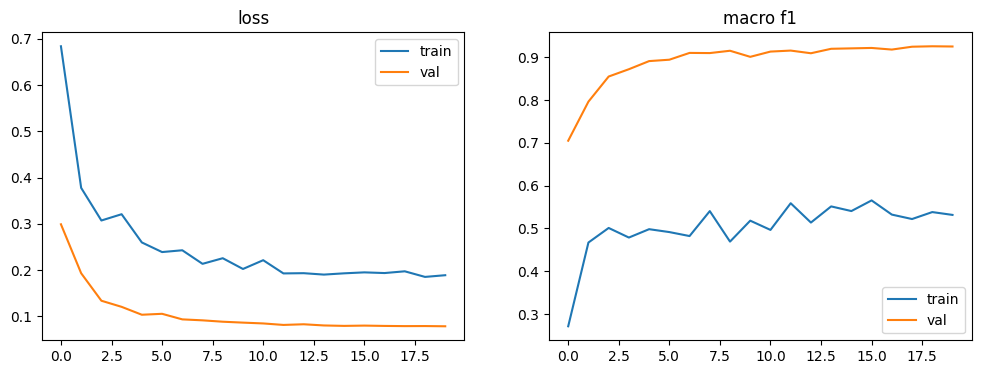

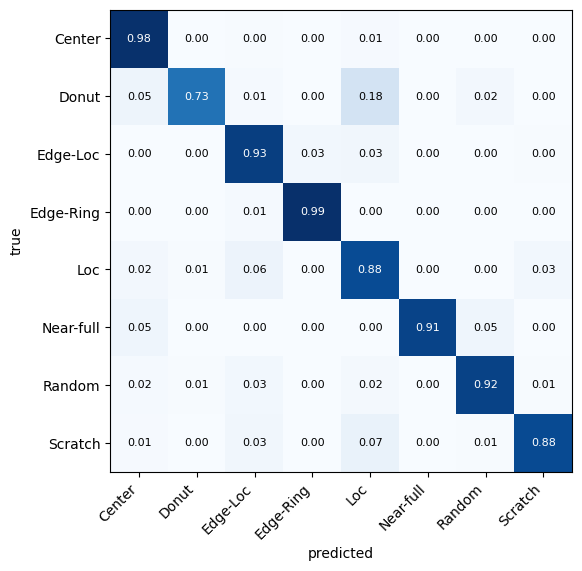

In [6]:
best = max(results, key=lambda k: results[k]['val_macro_f1'])  # pick on val, not test
m = results[best]
print('best on val:', best)

hist = json.load(open(f'{out}/{best}/history.json'))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for s in ['train', 'val']:
    ax[0].plot([h[s]['loss'] for h in hist], label=s)
    ax[1].plot([h[s]['macro_f1'] for h in hist], label=s)
ax[0].set_title('loss'); ax[1].set_title('macro f1'); ax[0].legend(); ax[1].legend()
fig.savefig(f'{out}/training_curves.png', dpi=120, bbox_inches='tight')

cm = np.array(m['confusion_matrix'])
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cmn, cmap='Blues')
ax.set_xticks(range(len(cm)), m['class_names'], rotation=45, ha='right')
ax.set_yticks(range(len(cm)), m['class_names'])
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f'{cmn[i, j]:.2f}', ha='center', va='center', fontsize=8, color='white' if cmn[i, j] > .5 else 'black')
ax.set_xlabel('predicted'); ax.set_ylabel('true')
fig.savefig(f'{out}/confusion_matrix.png', dpi=120, bbox_inches='tight')

## explanation maps

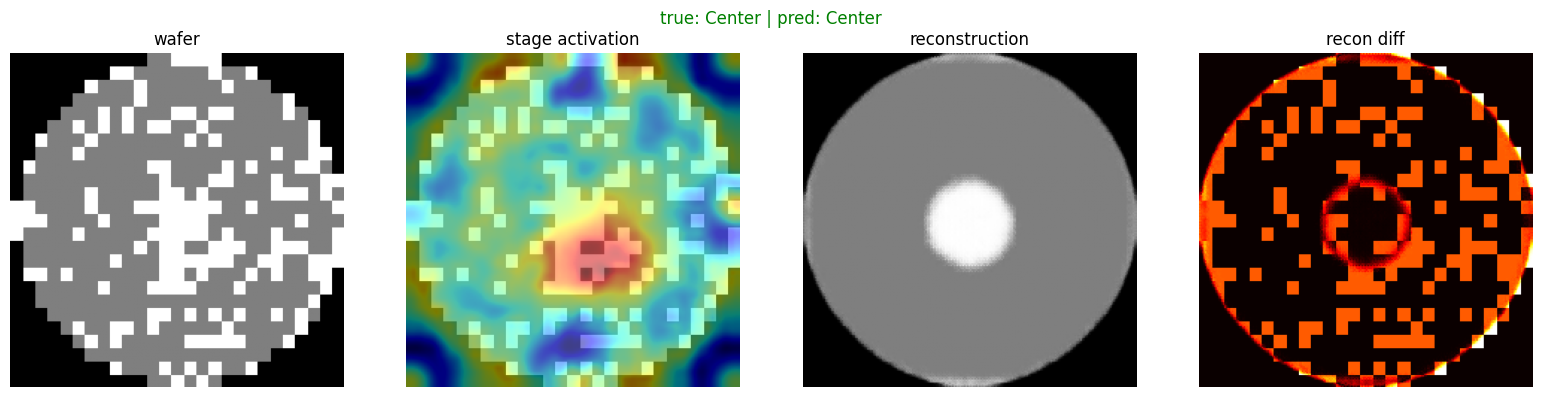

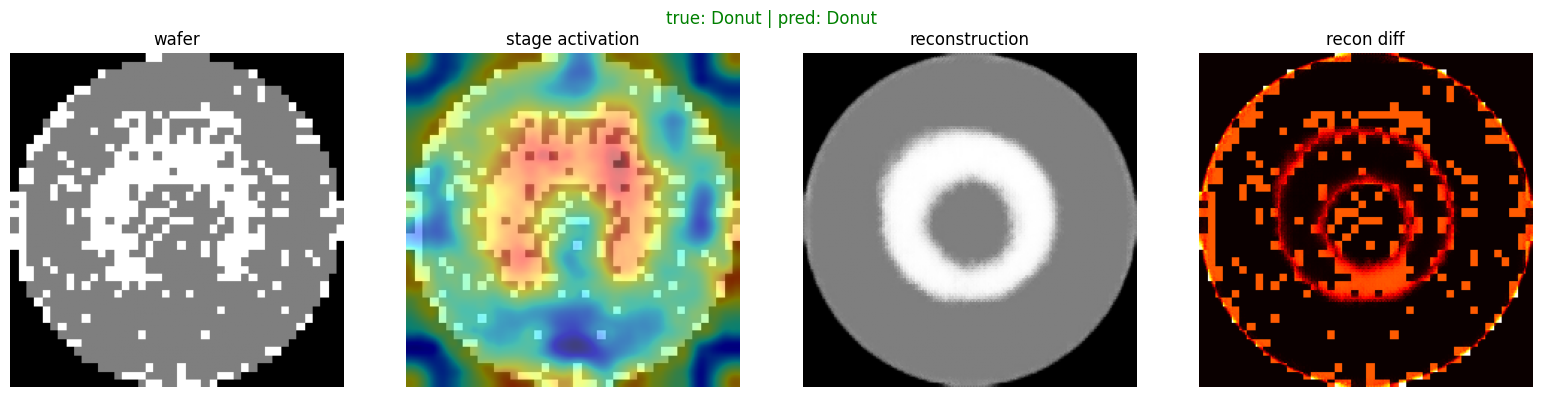

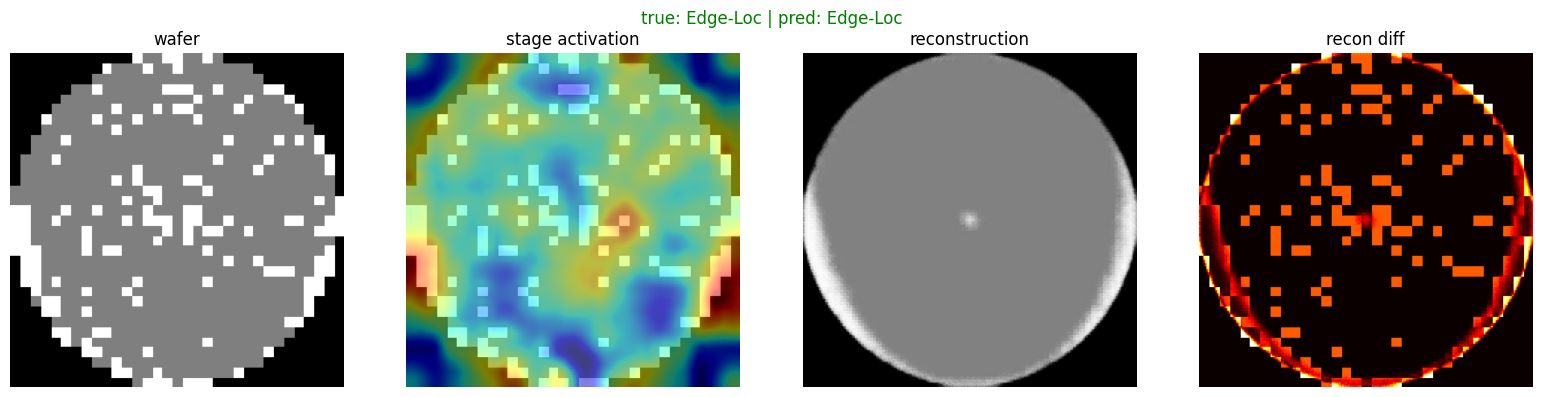

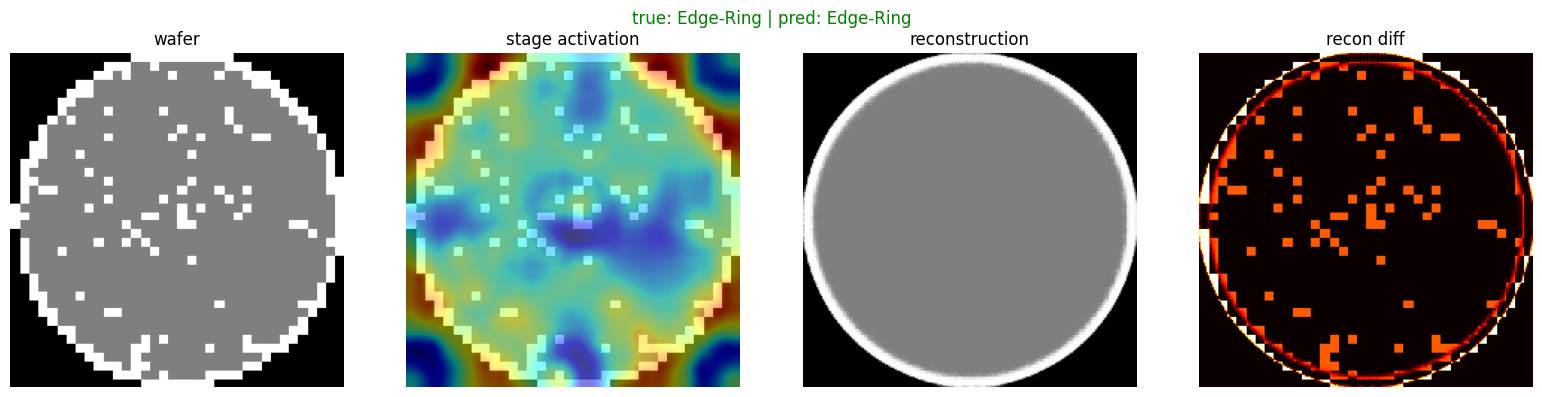

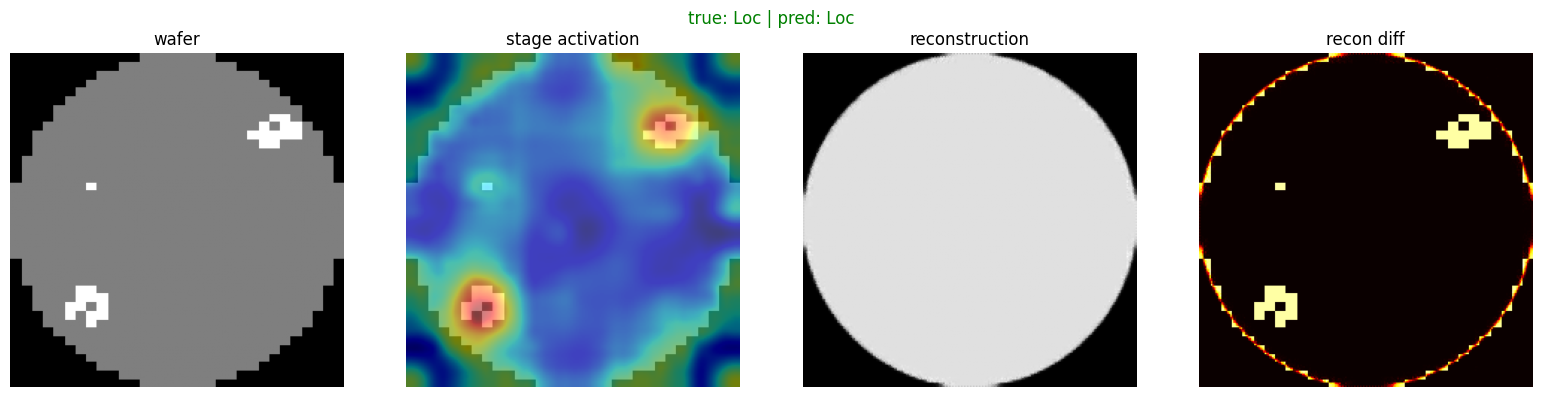

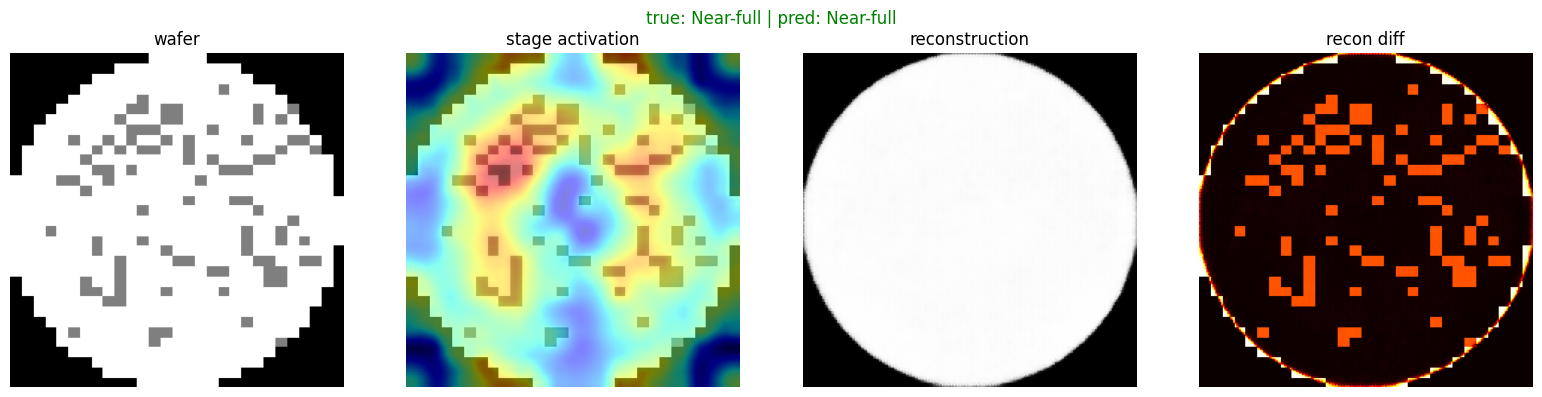

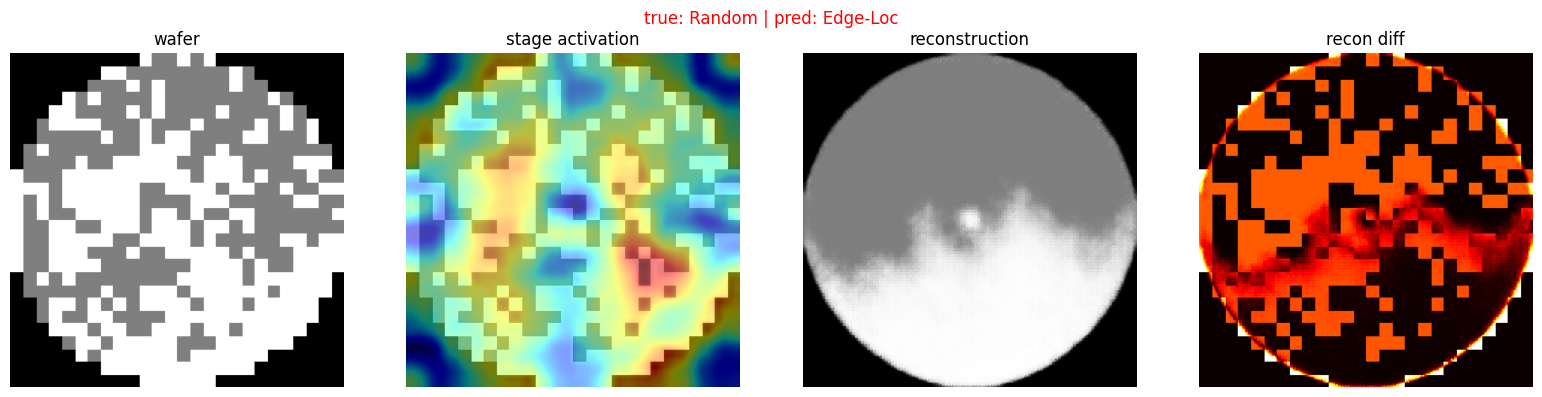

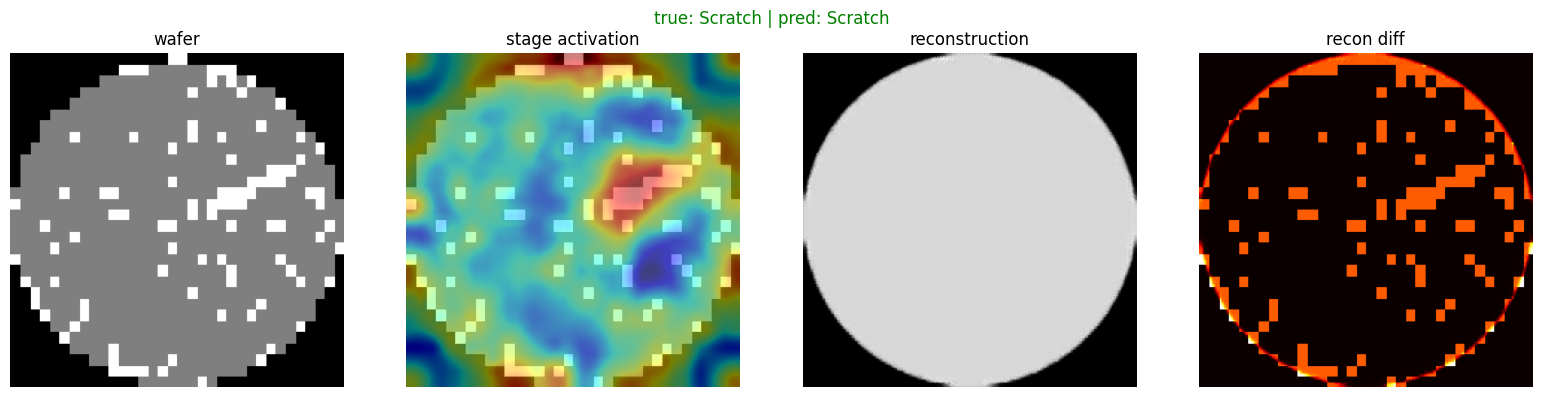

In [7]:
from waferdefect.model import WaferSwin
from waferdefect.explain import plot_explanation

ckpt = torch.load(f'{out}/{best}/best.pt', map_location='cuda')
names = ckpt['class_names']
model = WaferSwin(len(names), pretrained=False).cuda().eval()
model.load_state_dict(ckpt['model_state'])

train_df, _, test_df, _ = data.split(df)
test_ds = data.WaferDataset(test_df)
os.makedirs(f'{out}/explain', exist_ok=True)
for c, name in enumerate(names):
    i = test_df.index[test_df['label'] == c][0]
    x, y = test_ds[i]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).cuda())[0].argmax(1).item()
    plot_explanation(model, x, names[y], names[pred], save_path=f'{out}/explain/{name}.png')

## drift check

    step        chi2       p_value  drift                     top_classes
0      0    7.286612  3.996604e-01  False   [Edge-Ring, Edge-Loc, Random]
1      1    6.849846  4.446796e-01  False        [Scratch, Donut, Random]
2      2    6.920359  4.372189e-01  False      [Donut, Scratch, Edge-Loc]
3      3    5.991056  5.407941e-01  False     [Scratch, Donut, Near-full]
4      4   12.832185  7.630427e-02  False        [Scratch, Donut, Random]
5      5    7.334757  3.948766e-01  False          [Scratch, Center, Loc]
6      6   14.060123  5.012229e-02  False          [Scratch, Loc, Random]
7      7    6.802818  4.496952e-01  False           [Scratch, Donut, Loc]
8      8   29.273668  1.289690e-04   True  [Scratch, Edge-Loc, Edge-Ring]
9      9   87.209781  4.623051e-16   True  [Edge-Loc, Scratch, Edge-Ring]
10    10  152.912552  9.923454e-30   True  [Edge-Loc, Edge-Ring, Scratch]
11    11  274.425348  1.734319e-55   True  [Edge-Loc, Edge-Ring, Scratch]
12    12  260.322469  1.756625e-52   T

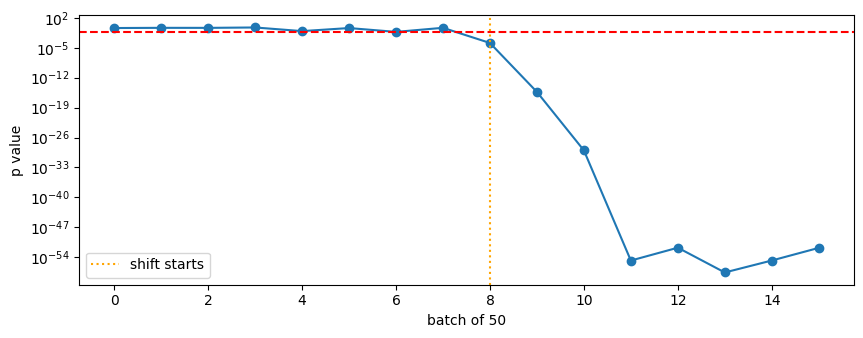

In [8]:
from waferdefect.drift import DriftMonitor
from torch.utils.data import DataLoader

@torch.no_grad()
def predict(frame):
    dl = DataLoader(data.WaferDataset(frame), batch_size=512, num_workers=workers)
    with torch.autocast('cuda', dtype=torch.bfloat16, enabled=torch.cuda.is_bf16_supported()):
        return np.concatenate([model(x.cuda())[0].argmax(1).cpu().numpy() for x, _ in dl])

ref = np.bincount(predict(train_df), minlength=len(names))

# 400 normal wafers then 400 where Edge-Loc + Scratch are 80%
shift_ids = [names.index('Edge-Loc'), names.index('Scratch')]
normal = test_df.sample(400, random_state=0)
shifted = pd.concat([test_df[test_df.label.isin(shift_ids)].sample(320, replace=True, random_state=0),
                     test_df[~test_df.label.isin(shift_ids)].sample(80, replace=True, random_state=0)]).sample(frac=1, random_state=0)
stream = predict(pd.concat([normal, shifted]))

mon = DriftMonitor(ref, names, window_size=200)
for i in range(0, len(stream), 50):
    mon.ingest(stream[i:i + 50])
h = pd.DataFrame(mon.history)
first = h.loc[h.drift & (h.step >= 8), 'step'].min()
false_alarms = int(h.loc[h.step < 8, 'drift'].sum())
print(h[['step', 'chi2', 'p_value', 'drift', 'top_classes']])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(h.step, h.p_value, marker='o')
ax.axhline(0.05, ls='--', c='r')
ax.axvline(8, ls=':', c='orange', label='shift starts')
ax.set_yscale('log'); ax.set_xlabel('batch of 50'); ax.set_ylabel('p value'); ax.legend()
fig.savefig(f'{out}/drift_monitor.png', dpi=120, bbox_inches='tight')
drift = {'first_alert_step': None if pd.isna(first) else int(first),
         'batches_after_shift': None if pd.isna(first) else int(first) - 8,
         'false_alarms_before_shift': false_alarms}

## summary

In [9]:
summary = {
    'gpu': torch.cuda.get_device_name(0),
    'n_wafers': len(df),
    'runs': {k: {'val_f1': round(v['val_macro_f1'], 4), 'test_f1': round(v['test_macro_f1'], 4),
                 'test_acc': round(v['test_accuracy'], 4), 'epoch': v['best_epoch'], 'min': v['minutes']}
             for k, v in results.items()},
    'best_on_val': best,
    'per_class': {k: {c: [round(v['per_class'][c]['precision'], 3), round(v['per_class'][c]['recall'], 3)]
                      for c in v['class_names']} for k, v in results.items()},
    'drift': drift,
}
json.dump(summary, open(f'{out}/summary.json', 'w'), indent=2)
shutil.copytree(out, drive_out, dirs_exist_ok=True)
print(json.dumps(summary, indent=2))

{
  "gpu": "NVIDIA A100-SXM4-80GB",
  "n_wafers": 25519,
  "runs": {
    "base": {
      "val_f1": 0.7488,
      "test_f1": 0.753,
      "test_acc": 0.7868,
      "epoch": 17,
      "min": 8.8
    },
    "no_mixup": {
      "val_f1": 0.7747,
      "test_f1": 0.7727,
      "test_acc": 0.8012,
      "epoch": 19,
      "min": 8.3
    },
    "sampler_only": {
      "val_f1": 0.9128,
      "test_f1": 0.9077,
      "test_acc": 0.936,
      "epoch": 19,
      "min": 8.2
    },
    "weights_only": {
      "val_f1": 0.7915,
      "test_f1": 0.7941,
      "test_acc": 0.8297,
      "epoch": 19,
      "min": 8.2
    },
    "no_rebalance": {
      "val_f1": 0.9256,
      "test_f1": 0.9169,
      "test_acc": 0.9457,
      "epoch": 19,
      "min": 8.3
    }
  },
  "best_on_val": "no_rebalance",
  "per_class": {
    "base": {
      "Center": [
        0.936,
        0.924
      ],
      "Donut": [
        0.566,
        0.988
      ],
      "Edge-Loc": [
        0.705,
        0.617
      ],
      "E